# CSE445 Machine Learning Project
## Animal Image Classification Pipeline




In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & VGG16 for Feature Extraction
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Scikit-Learn Models & XGBoost
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- GPU check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) detected: {[gpu.name for gpu in gpus]}")
    # Optional: allow memory growth to avoid TF grabbing all VRAM at once
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
else:
    print("No GPU detected by TensorFlow. Check your CUDA/cuDNN + tensorflow-gpu install.")

GPU(s) detected: ['/physical_device:GPU:0']


In [2]:
import os
import shutil
import tensorflow as tf

BASE_DIR = r"F:\CSE445 Project\data"
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
QUARANTINE_DIR = os.path.join(BASE_DIR, "_bad_files")

def scan_and_quarantine(base_dir, move_bad_files=False):
    bad_files = []
    for root, _, files in os.walk(base_dir):
        # Skip the quarantine folder itself on repeat runs
        if os.path.normpath(root).startswith(os.path.normpath(QUARANTINE_DIR)):
            continue
        for fname in files:
            fpath = os.path.join(root, fname)

            # 1. Flag files with an extension Keras doesn't accept
            if not fname.lower().endswith(VALID_EXTENSIONS):
                bad_files.append((fpath, "unsupported extension"))
                continue

            # 2. Flag files whose CONTENT isn't actually a decodable image
            #    (this catches mislabeled extensions and truncated/corrupt files)
            try:
                raw = tf.io.read_file(fpath)
                tf.io.decode_image(raw)
            except Exception as e:
                bad_files.append((fpath, f"failed to decode: {e}"))

    print(f"Scan complete. Found {len(bad_files)} problematic file(s).\n")
    for fpath, reason in bad_files:
        print(f" - {fpath}\n     reason: {reason}")

    if move_bad_files and bad_files:
        os.makedirs(QUARANTINE_DIR, exist_ok=True)
        for fpath, _ in bad_files:
            dest = os.path.join(QUARANTINE_DIR, os.path.basename(fpath))
            shutil.move(fpath, dest)
        print(f"\nMoved {len(bad_files)} file(s) to {QUARANTINE_DIR}")

    return bad_files

# First pass: report AND move any bad files so they can't break loading below
bad_files_found = scan_and_quarantine(BASE_DIR, move_bad_files=True)

Scan complete. Found 0 problematic file(s).



In [3]:
import os
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np

# Local dataset path (Windows path, using raw string to avoid escape issues)
BASE_DIR = r"F:\CSE445 Project\data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Function to load dataset without shuffling so labels align perfectly for Scikit-Learn
def load_data(folder_name):
    dir_path = os.path.join(BASE_DIR, folder_name)
    return image_dataset_from_directory(
        dir_path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

print("Loading datasets from local disk ...")
train_ds = load_data('train')
val_ds = load_data('val')
test_ds = load_data('test')

# Extract exact integer labels to use for Scikit-Learn training
y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_val = np.concatenate([y for x, y in val_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)

# Get class names for later
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Loading datasets from local disk ...
Found 347 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Classes found: ['cat', 'cow', 'dog', 'lamb', 'zebra']


In [4]:
# Load VGG16 without the final classification layer (include_top=False)
# pooling='avg' flattens the output into a neat 512-dimensional vector per image.
vgg_feature_extractor = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

def extract_features(dataset):
    features = []
    for images, labels in dataset:
        # Preprocess images to match VGG16's specific formatting requirements
        preprocessed_images = preprocess_input(images)
        # Extract features
        extracted = vgg_feature_extractor.predict(preprocessed_images, verbose=0)
        features.append(extracted)
    return np.vstack(features)

print("Extracting features from Train set...")
X_train = extract_features(train_ds)

print("Extracting features from Validation set...")
X_val = extract_features(val_ds)

print("Extracting features from Test set...")
X_test = extract_features(test_ds)

print(f"Feature extraction complete! Training features shape: {X_train.shape}")

Extracting features from Train set...
Extracting features from Validation set...
Extracting features from Test set...
Feature extraction complete! Training features shape: (347, 512)


Training base learners...
  Logistic Regression: Test Accuracy = 98.67%
  Random Forest: Test Accuracy = 97.33%
  SVM: Test Accuracy = 98.67%
  XGBoost: Test Accuracy = 98.67%

Training Hybrid Stacking Classifier...

Validation Accuracy: 100.00%

✅ Hybrid Model finished. Test Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

         cat       1.00      1.00      1.00        15
         cow       1.00      1.00      1.00        15
         dog       1.00      1.00      1.00        15
        lamb       1.00      1.00      1.00        15
       zebra       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



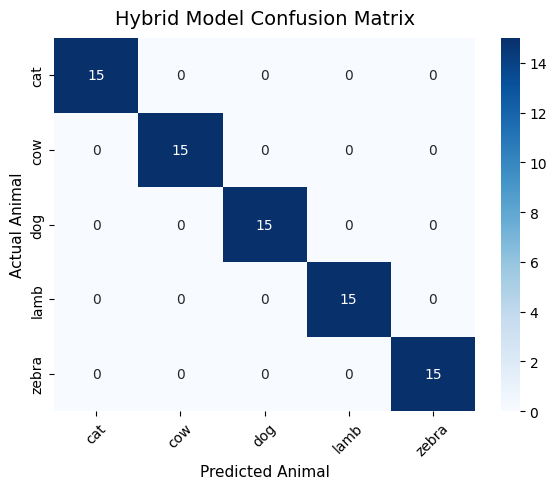

Calculating Learning Curve... (This might take a few seconds)


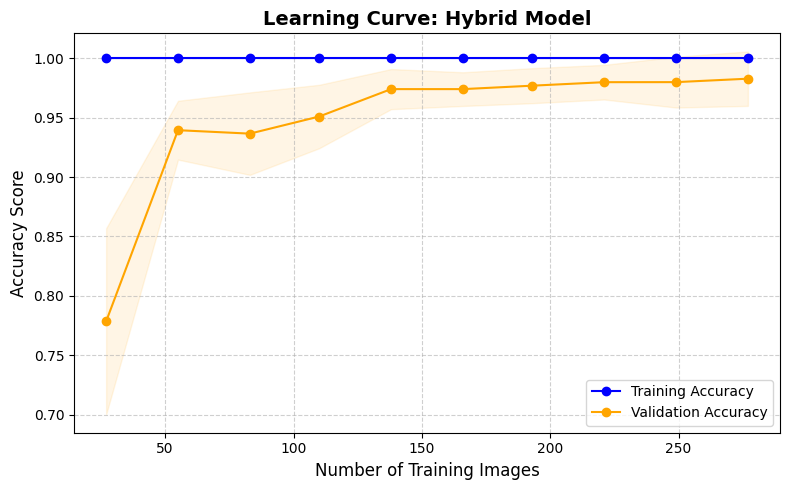

,Model,Test Accuracy
4,Hybrid Model (Stacking),1.000000
0,Logistic Regression,0.986667
2,SVM,0.986667
3,XGBoost,0.986667
1,Random Forest,0.973333


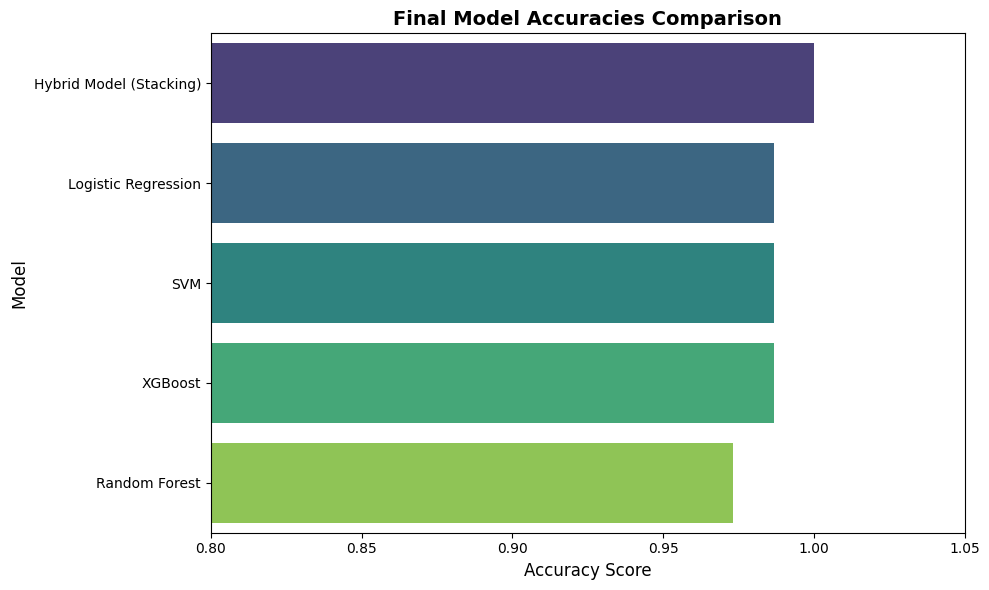

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Feature Scaling ---
# LR and SVM are sensitive to feature magnitude, so we standardize the VGG16
# features (zero mean, unit variance). The scaler is fit ONLY on the training
# set to avoid leaking val/test statistics. RF and XGBoost don't need scaling,
# but applying it uniformly keeps every base learner on the same input.
scaler_hybrid = StandardScaler()
X_train_scaled = scaler_hybrid.fit_transform(X_train)
X_val_scaled = scaler_hybrid.transform(X_val)
X_test_scaled = scaler_hybrid.transform(X_test)

# --- Base Learners ---
# These are trained locally in this section so the notebook is fully
# self-contained (it no longer depends on lr_model/rf_model/svm_model/xgb_model
# being defined by other teammates' cells earlier in a shared session).
print("Training base learners...")
lr_model = LogisticRegression(max_iter=5000, C=1.0, random_state=42)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
xgb_model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)

for name, model in [('Logistic Regression', lr_model), ('Random Forest', rf_model),
                     ('SVM', svm_model), ('XGBoost', xgb_model)]:
    model.fit(X_train_scaled, y_train)
    acc_i = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"  {name}: Test Accuracy = {acc_i * 100:.2f}%")

# --- Hybrid Stacking Classifier ---
print("\nTraining Hybrid Stacking Classifier...")
hybrid_estimators = [
    ('lr', lr_model),
    ('rf', rf_model),
    ('svm', svm_model),
    ('xgb', xgb_model)
]

hybrid_model = StackingClassifier(
    estimators=hybrid_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False
)
hybrid_model.fit(X_train_scaled, y_train)

# --- Validation Check ---
y_val_pred = hybrid_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc * 100:.2f}%")

# --- Predictions & Accuracy ---
y_pred = hybrid_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\n\u2705 Hybrid Model finished. Test Accuracy: {acc * 100:.2f}%\n")

# --- 1. Classification Report ---
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 2. Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid Model Confusion Matrix', fontsize=14, pad=10)
plt.ylabel('Actual Animal', fontsize=11)
plt.xlabel('Predicted Animal', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 3. Learning Curve ---
print("Calculating Learning Curve... (This might take a few seconds)")
np.random.seed(42)
shuffle_indices = np.random.permutation(len(X_train_scaled))
X_train_shuffled = X_train_scaled[shuffle_indices]
y_train_shuffled = y_train[shuffle_indices]

train_sizes, train_scores, test_scores = learning_curve(
    hybrid_model, X_train_shuffled, y_train_shuffled,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="orange", label="Validation Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
plt.title("Learning Curve: Hybrid Model", fontsize=14, fontweight='bold')
plt.xlabel("Number of Training Images", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Final Comparison Table ---
results = [
    {'Model': 'Logistic Regression', 'Test Accuracy': accuracy_score(y_test, lr_model.predict(X_test_scaled))},
    {'Model': 'Random Forest', 'Test Accuracy': accuracy_score(y_test, rf_model.predict(X_test_scaled))},
    {'Model': 'SVM', 'Test Accuracy': accuracy_score(y_test, svm_model.predict(X_test_scaled))},
    {'Model': 'XGBoost', 'Test Accuracy': accuracy_score(y_test, xgb_model.predict(X_test_scaled))},
    {'Model': 'Hybrid Model (Stacking)', 'Test Accuracy': accuracy_score(y_test, hybrid_model.predict(X_test_scaled))}
]

results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
display(results_df)

# --- Final Accuracy Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Test Accuracy', y='Model', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Final Model Accuracies Comparison', fontsize=14, fontweight='bold')
plt.xlim(0.8, 1.05)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()